In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 1 Prédiction de la réussite des étudiants

Le fichier students.csv contient des données relatives à la prédiction de l’abandon ou de la réussite d’étudiants de l’enseignement supérieur en fin de cursus. Chaque donnée représente un étudiant et contient des informations connues au moment de l’inscription de l’étudiant - parcours scolaire, données démographiques et facteurs socio-économiques.

Pour plus d’information, ce dataset est décrit sur le site de l’UCI.

1. Chargez et préparez les données

In [3]:
df = pd.read_csv('students.csv', sep=';')
y = df['Target']
y = y.map({'Graduate': 0, 'Dropout': 1, 'Enrolled': 2})
X = df.drop('Target', axis =1)

Combien de données et de caractéristiques contient ce dataset ? Quelles sont les proportions de données dans chaque classe ? Les classes sont-elles équilibrées ?

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
df.groupby(['Target'])['Target'].count()

Target
Dropout     1421
Enrolled     794
Graduate    2209
Name: Target, dtype: int64

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The dataset has 36 features and 4424 rows. We can see that the classes are heavily imbalanced. The class "Graduate" (0) has approximately 50% representation followed by 32% for "Dropout" (1) and 18% for "Enrolled" (2). Class imbalance can lead to problems in model prediction.
  </p>
</div>

2. Séparez les données en un jeu d’entraînement et un jeu de test

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size =0.5, random_state =42)

print(f"Train: {len(y_train)/len(y)*100:.2f}%")
print(f"Test: {len(y_test)/len(y)*100:.2f}%")

Train: 50.00%
Test: 50.00%


3. Standardisez les données

In [8]:
sc = StandardScaler(with_mean=True , with_std=True)
sc = sc.fit(X_train)
Xa_n = sc.transform(X_train)
Xt_n = sc.transform(X_test)

4. Déterminez les hyperparamètres optimaux du SVM à noyaux RBF en utilisant la validation
croisée à 3 folds

In [9]:
svc = SVC(kernel="rbf")
parameters = {'C':[0.1, 1, 10], 'gamma':[0.01, 0.1, 1, 10, 100]}
clf = GridSearchCV(svc, parameters, cv=3)

5. Entrainez un SVM à noyaux RBF avec les hyperparamètres optimaux trouvés sur l’ensemble
d’entraînement

In [10]:
clf.fit(Xa_n, y_train)

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1, 10, 100]})

6. Évaluez les performances du modèle sur l’ensemble de test

In [11]:
y_pred = clf.predict(Xt_n)
acc = accuracy_score(y_test, y_pred)
print(f"Accuaracy = {acc*100:.2f}%")

Accuaracy = 75.09%


7. Affichez la matrice de confusion en utilisant confusion_matrix et  confusionMatrixDisplay de Scikit-learn.

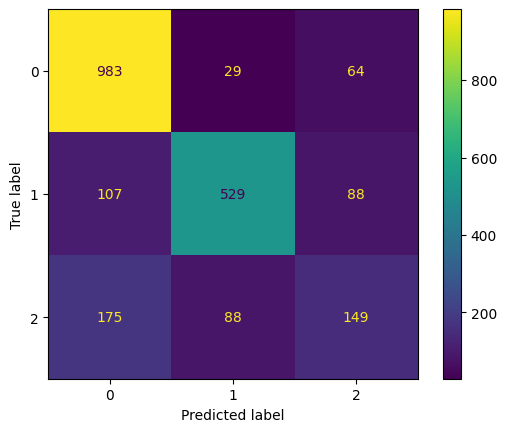

In [12]:
y_pred = clf.predict(Xt_n)
conf = confusion_matrix(y_test , y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf , display_labels=clf.classes_)
disp.plot()
plt.show()

En consultant la documentation, expliquez ce que contient cette matrice et en quoi elle peut être utile.

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The confusion matrix shows the number of good predictions in the main diagonal and each case of miss classification in the other cells. That way, it becomes easy to see the classes with the highest number of mistakes.
  </p>
</div>

8. Les valeurs données par la fonction score de Scikit-learn peuvent être calculées à partir des valeurs de la matrice de confusion. Vérifiez-le et expliquez pourquoi ce score n’est pas pertinent pour notre problème.

In [12]:
rig = conf.diagonal().sum()
tot = conf.sum()

score = rig/tot

print(f"Score = {100*score:.2f}%")

Score = 76.05%


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The score value is not capable of showing all the details of the prediction that was made. It shows the overall accuracy, but for this classification with more than 2 classes it is important to highlight which class presents the biggest problem for classification, in order to identify a method for improvement.
  </p>
  <p>
    In addition, as the classes are unbalanced, this value may be biased, since as there were many correct answers in the majority class the score appears high, but in reality the accuracy in the minority class was quite unsatisfactory and this is not being represented in the Score value.
  </p>
</div>

9. Que pouvez-vous en conclure sur le comportement des méthodes de SVM à noyaux RBF ?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see that the SVM with the rbf kernel is extremely sensitive to data imbalance. Most of the data in class 2 were not well classified because the decision boundary was more biased towards the majoritary classes.
  </p>
</div>

10. Scikit-learn propose une fonction balanced_accuracy_score qui modifie le score pour tenir compte des classes déséquilibrées. Calculez ce score et comparez-le au score classique.

In [14]:
print(f"Accuaracy = {acc*100:.2f}%")
print(f"Balanced Accuaracy: {balanced_accuracy_score(y_test, y_pred).item()*100:.2f}%")

Accuaracy = 75.09%
Balanced Accuaracy: 66.86%


11. Ce score est également calculable à partir de la matrice de confusion. Vérifiez-le et donnez votre analyse de ces résultats.

In [15]:
recall_per_class = conf.diagonal() / conf.sum(axis=1) 
balanced_acc = recall_per_class.mean()  

print(f"Balanced Accuracy : {100*balanced_acc:.2f}%")


Balanced Accuracy : 66.86%


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The result of the Balanced Score is lower than the Score, this value better represents the result, as the effect of the classification errors of class 2 acquires a weight equivalent to the other classes and begins to better impact the result.
  </p>
</div>

## 2 Bonus : Recommencez avec un noyau polynomial
En guise d’exercice bonus, reprenez les questions de l’exercice précédent en remplaçant le noyau RBF par un noyau polynomial.

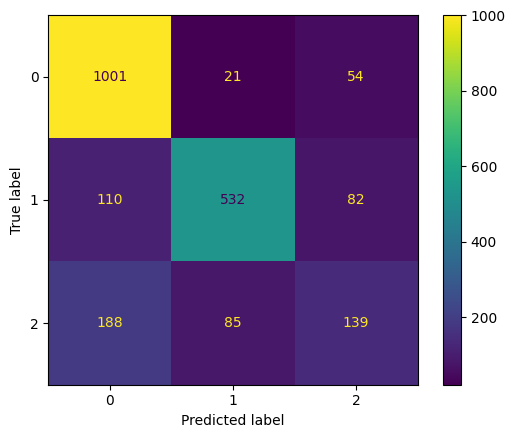

Accuaracy: 75.59%
Balanced Accuaracy: 66.75%


In [17]:
svc = SVC(kernel="poly")
parameters = {'C':[0.1, 1, 10], 'degree':[1, 2, 3, 4, 5]}
clf = GridSearchCV(svc, parameters, cv=3)

clf.fit(Xa_n, y_train)
# print(clf.get_params()['C'])
# print(clf.get_params()['degree'])

y_pred = clf.predict(Xt_n)
conf = confusion_matrix(y_test , y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf , display_labels=clf.classes_)
disp.plot()
plt.show()

print(f"Accuaracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Balanced Accuaracy: {balanced_accuracy_score(y_test, y_pred).item()*100:.2f}%")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The SVM with polynomial kernel performed very similarly to the RBF kernel, with a small increase in overall accuracy but no improvement in balanced accuracy. This indicates that it continues to favor the majority class and has difficulty dealing with imbalanced classes.
  </p>
</div>